Saving e2ecc796334c7e4a3bc57e60d0a4b0ce.jpg to e2ecc796334c7e4a3bc57e60d0a4b0ce.jpg


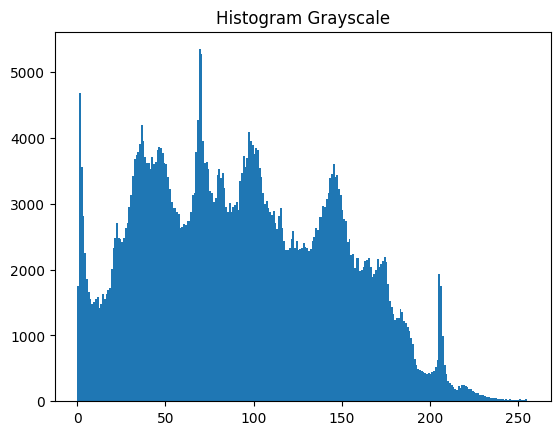

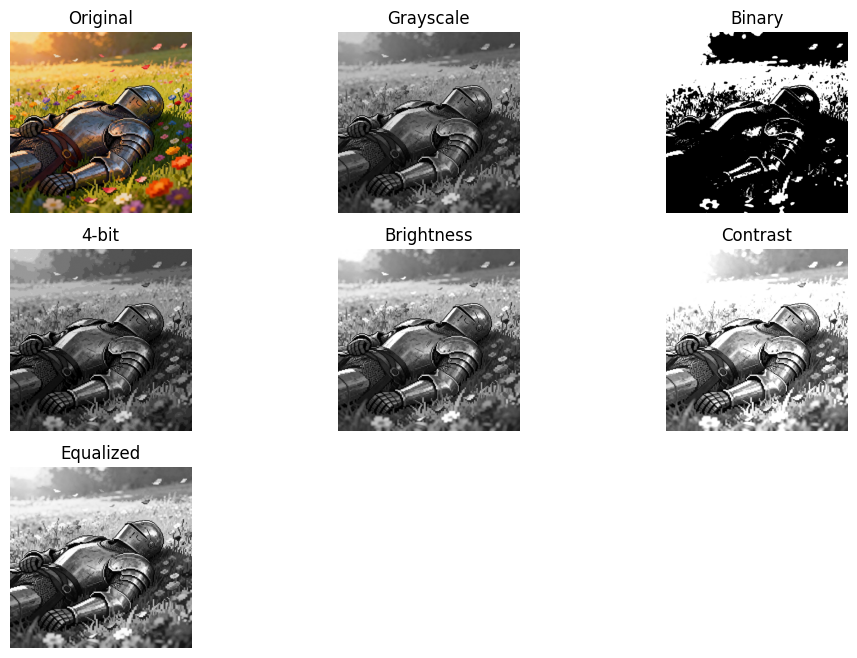

In [ ]:
# Install library (kalau belum ada)
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload gambar
from google.colab import files
uploaded = files.upload()

# Ambil nama file
image_path = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. RGB ke Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# 2. Grayscale ke Biner
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 3. Grayscale ke m-bit (contoh: 4-bit)
m = 4
levels = 2**m
gray_mbit = np.floor(gray / (256 / levels)) * (256 / levels)
gray_mbit = gray_mbit.astype(np.uint8)

# 4. Brightness (tambah nilai)
brightness = cv2.convertScaleAbs(gray, alpha=1, beta=50)

# 5. Contrast (skala)
contrast = cv2.convertScaleAbs(gray, alpha=2, beta=0)

# 6. Histogram
plt.figure()
plt.title("Histogram Grayscale")
plt.hist(gray.ravel(), bins=256, range=[0,256])
plt.show()

# 7. Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Tampilkan hasil
titles = ['Original', 'Grayscale', 'Binary', '4-bit',
          'Brightness', 'Contrast', 'Equalized']

images = [img_rgb, gray, binary, gray_mbit,
          brightness, contrast, equalized]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()